In [22]:
import numpy as np
import pandas as pd

In [23]:
data = pd.read_csv(r"C:\Users\Sudesh Surjan\Desktop\austin_weather.csv")
data

,Date,TempHighF,TempAvgF,TempLowF,DewPointHighF,DewPointAvgF,DewPointLowF,HumidityHighPercent,HumidityAvgPercent,HumidityLowPercent,...,SeaLevelPressureAvgInches,SeaLevelPressureLowInches,VisibilityHighMiles,VisibilityAvgMiles,VisibilityLowMiles,WindHighMPH,WindAvgMPH,WindGustMPH,PrecipitationSumInches,Events
0,2013-12-21,74,60,45,67,49,43,93,75,57,...,29.68,29.59,10,7,2,20,4,31,0.46,"Rain , Thunderstorm"
1,2013-12-22,56,48,39,43,36,28,93,68,43,...,30.13,29.87,10,10,5,16,6,25,0,
2,2013-12-23,58,45,32,31,27,23,76,52,27,...,30.49,30.41,10,10,10,8,3,12,0,
3,2013-12-24,61,46,31,36,28,21,89,56,22,...,30.45,30.3,10,10,7,12,4,20,0,
4,2013-12-25,58,50,41,44,40,36,86,71,56,...,30.33,30.27,10,10,7,10,2,16,T,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1314,2017-07-27,103,89,75,71,67,61,82,54,25,...,29.97,29.88,10,10,10,12,5,21,0,
1315,2017-07-28,105,91,76,71,64,55,87,54,20,...,29.9,29.81,10,10,10,14,5,20,0,
1316,2017-07-29,107,92,77,72,64,55,82,51,19,...,29.86,29.79,10,10,10,12,4,17,0,
1317,2017-07-30,106,93,79,70,68,63,69,48,27,...,29.91,29.87,10,10,10,13,4,20,0,


In [28]:
#drop the unnecessary columns
data = data.drop(columns=[col for col in["Events","Date", "SeaLevelPressureLowInches"] if col in data.columns])

In [38]:
data = data.replace('T',0.0)
data = data.replace('-',0.0)
data.to_csv(r"C:\Users\Sudesh Surjan\Desktop\austin_weather_final.csv")

In [39]:
import numpy as np
import pandas as pd
import sklearn as sk
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [40]:
data.to_csv("austin_weather_final.csv")
data

,TempHighF,TempAvgF,TempLowF,DewPointHighF,DewPointAvgF,DewPointLowF,HumidityHighPercent,HumidityAvgPercent,HumidityLowPercent,SeaLevelPressureHighInches,SeaLevelPressureAvgInches,VisibilityHighMiles,VisibilityAvgMiles,VisibilityLowMiles,WindHighMPH,WindAvgMPH,WindGustMPH,PrecipitationSumInches
0,74,60,45,67,49,43,93,75,57,29.86,29.68,10,7,2,20,4,31,0.46
1,56,48,39,43,36,28,93,68,43,30.41,30.13,10,10,5,16,6,25,0
2,58,45,32,31,27,23,76,52,27,30.56,30.49,10,10,10,8,3,12,0
3,61,46,31,36,28,21,89,56,22,30.56,30.45,10,10,7,12,4,20,0
4,58,50,41,44,40,36,86,71,56,30.41,30.33,10,10,7,10,2,16,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1314,103,89,75,71,67,61,82,54,25,30.04,29.97,10,10,10,12,5,21,0
1315,105,91,76,71,64,55,87,54,20,29.97,29.9,10,10,10,14,5,20,0
1316,107,92,77,72,64,55,82,51,19,29.91,29.86,10,10,10,12,4,17,0
1317,106,93,79,70,68,63,69,48,27,29.96,29.91,10,10,10,13,4,20,0


In [45]:
X = data.drop(['PrecipitationSumInches'],axis = 1)

Y = data["PrecipitationSumInches"]

In [52]:
#reshaping it into 2d vector

day_index = 798
days = [i for i in range(Y.size)]

In [54]:
#initialize the linear regression classifier

clf = LinearRegression()

#train the classifiera
clf.fit(X,Y)

LinearRegression()

the precipitation trend graph:


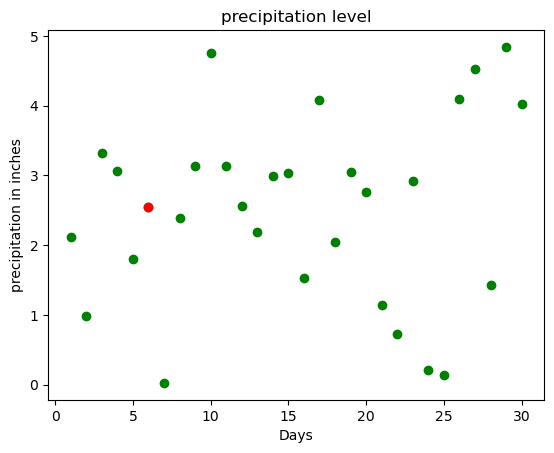

In [60]:
#plot a graph

days = np.arange(1, 31)            # 1 se 30 din
Y = np.random.rand(30) * 5         # random precipitation data

day_index = 5 

print("the precipitation trend graph:")
plt.scatter(days, Y, color='g')                               # sab points green
plt.scatter(days[day_index], Y[day_index], color='r')         # ek point red
plt.title("precipitation level")
plt.xlabel("Days")
plt.ylabel("precipitation in inches")
plt.show()
x_vis= X.filter(['TempAvgF','DewPointAvgF','HumidityAvgPercent','SeaLevelPressureAvgInches','VisibilityAvgMiles','WindAvgMPH'])


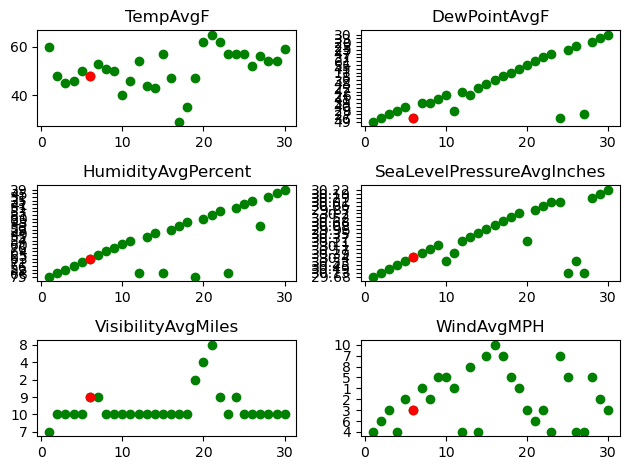

In [64]:
for i in range(x_vis.columns.size):
    plt.subplot(3, 2, i+1)
    plt.scatter(days, x_vis[x_vis.columns[i]].iloc[:30], color='g')
    plt.scatter(days[day_index], x_vis[x_vis.columns[i]].iloc[day_index], color='r')
    plt.title(x_vis.columns[i])
plt.tight_layout()
plt.show()